# DAI Mission
**Data & AI in Economics | TU Dortmund**



## 1. Team

| Role | Name | Student ID |
|------|------|------------|
| Member 1 | Nishadhine Udaya Chenthir| |
| Member 2 |Suyashi Agarwal| |


## 2. Mission Title & Research Question

**Title: *The Subjective Poverty Trap: Does Feeling Poor Erode Support for Redistribution?***

**Research question:**

Does subjectively feeling financially deprived — independent of objective income level and psychological value profile — causally reduce a European citizen's support for government-led income redistribution?

Comparing two individuals with the same objective income decile and the same moral value archetype, does the one who feels poorer express systematically weaker support for redistribution?

**Why it matters:** If the person who feels poorer does express systematically weaker support for redistribution, when comparing two individuals with the same objective income decile and the same moral value archetype?Welfare states are built on redistributive preferences. According to classical theory, people with low incomes should favour redistribution (Meltzer-Richard model). But if subjective financial stress produces individualistic cognition that undermines solidarity among those who would gain the most, this creates a self-reinforcing poverty trap at the political level. The understanding of this mechanism has direct implications for welfare state design and the behavioural roots of inequality across Europe.

## 3. Data

**Source:**  
*European Social Survey (ESS), Round 11 — 2023*
- Provider: Sikt / ESS ERIC
- URL: https://ess.sikt.no/en/datafile/242aaa39-3bbb-40f5-98bf-bfb1ce53d8ef
- Access: Free download after registration (academic use)
- Licence: European Social Survey data is licensed under CC BY-NC-SA 4.0


**Unit of observation:** One individual survey respondent (adult resident, ~ 50,000 respondents, 30 European countries)

**Disclaimer:** We performed data cleaning and processing to extract relevant features on "European Social Survey (ESS), Round 11 — 2023" data.

**Key variables:**

| Variable | Type | Role (feature / target / instrument / ...) | Description |
|----------|------|---------------------------------------------|-------------|
| **gincdif** | Ordinal 1-5 | Target Y | Govt should reduce income differences |
| **Y_support_redist** | Binary | Target Y (binary) | 1=supports redistribution |
| **T_subj_poor** | Binary | Treatment T | 0=comfortable/coping, 1=difficult/very difficult |
| **hinctnta** | Ordinal 1-10 | Confounder | Objective household income decile |
| **health** | Ordinal 1-5 | Confounder | Self-reported health (ESS11 module) |
| **ipcrtiv .... impfun** | Ordinal 1-6 | Unsupervised input | 21 Schwartz items (reverse-coded) |
| **agea** | Continuous | Confounder | Age |
| **eduyrs**| Continuous | Confounder | Years of education |
| **female** | Binary | Confounder | 1=female |
| **cntry** | Categorical | Fixed effect | Country |
| **pspwght** | Continuous | Weight | Post-stratification weight |


**Potential data quality issues:**  

**Extreme Missingness:** The objective income decile variable (hinctnta) is missing 54.6% of its values, and recoding standard missing-value sentinels resulted in 42,982 NaN cells across the dataset.

**Survey Fatigue:** Low respondent engagement is evident, as the pipeline had to drop 326 "straightliners" and 315 rows that were missing more than five Schwartz value items.

**Class Imbalances:** Derived target and treatment variables are highly skewed, notably subjective poverty (8,301 "not poor" vs. 2,096 "poor"), poor health (9,802 vs. 655), and support for redistribution (7,732 vs. 2,605).

**Measurement and Reporting Bias:** Key measures rely heavily on self-reporting (e.g., subjective income, reverse-coded Schwartz items), making them vulnerable to subjective interpretation and cultural biases.


In [6]:
# Data loading & first inspection
# ── replace with your own code ──────────────────────────────────────────
import pandas as pd
import numpy as np

# df = pd.read_csv(...)
# df.head()
# df.info()
# df.describe()


In [7]:
# ── 0. DEPENDENCIES ──────────────────────────────────────────────────────────
# !pip install dowhy econml scikit-learn umap-learn matplotlib seaborn

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PALETTE = ['#E91E63', '#2196F3', '#4CAF50', '#FF9800']
print('Libraries loaded OK.')

Libraries loaded OK.


In [8]:
#  1. LOAD CLEAN DATASET
df = pd.read_csv('/content/ESS11_clean.csv', low_memory=False)

# Normalise ALL column names to lowercase
df.columns = df.columns.str.lower().str.strip()

print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'All columns (lowercase):')
print(sorted(df.columns.tolist()))

Loaded: 10,461 rows x 41 columns
All columns (lowercase):
['agea', 'anweight', 'atchctr', 'atcherp', 'cntry', 'eduyrs', 'emplrel', 'female', 'gincdif', 'gndr', 'health', 'hincfel', 'hinctnta', 'hlthhmp', 'impdiffa', 'impenva', 'impfreea', 'impfuna', 'impricha', 'impsafea', 'imptrada', 'ipadvnta', 'ipbhprpa', 'ipcrtiva', 'ipeqopta', 'ipfrulea', 'ipgdtima', 'iphlppla', 'iplylfra', 'ipmodsta', 'iprspota', 'ipshabta', 'ipstrgva', 'ipsucesa', 'ipudrsta', 'poor_health', 'pplfair', 'ppltrst', 'pspwght', 't_subj_poor', 'y_support_redist']


In [9]:
# 2. DEFINE & DETECT VARIABLE LISTS

# All 21 Schwartz items (lowercase)
SCHWARTZ_WANTED = [
    'ipcrtiva','impricha','ipeqopta','ipshabta','impsafea',
    'impdiffa','ipfrulea','ipudrsta','ipmodsta','ipgdtima',
    'impfreea','iphlppla','ipsucesa','ipstrgva','ipadvnta',
    'ipbhprpa','iprspota','iplylfra','impenva','imptrada','impfuna'
]
SCHWARTZ_LABELS = [
    'Creativity','Wealth','Equality','Ability','Safety',
    'Adventure','Rules','Understanding','Modesty','Good time',
    'Freedom','Helping','Success','Strong govt','Thrill',
    'Proper behav.','Respect','Loyalty','Environment','Tradition','Fun'
]

# Only keep items actually present after lowercase normalisation
schwartz_present = [c for c in SCHWARTZ_WANTED if c in df.columns]
schwartz_labels  = [SCHWARTZ_LABELS[SCHWARTZ_WANTED.index(c)] for c in schwartz_present]

print(f'Schwartz items found: {len(schwartz_present)}/21')
if len(schwartz_present) == 0:
    # Emergency fallback: auto-detect any column that starts with ip or imp
    schwartz_present = [c for c in df.columns if c.startswith('ip') or
                        (c.startswith('imp') and c not in ['impenv'])]
    schwartz_present += [c for c in df.columns if c in ['impenv','imptrad','impfun',
                                                          'imprich','impfree','impdiff',
                                                          'impsafe','imphlppl']]
    schwartz_present = sorted(set(schwartz_present))
    schwartz_labels  = schwartz_present   # use raw names as labels if fallback
    print(f'  [FALLBACK] Auto-detected Schwartz-like columns: {schwartz_present}')

assert len(schwartz_present) > 0, \
    'ERROR: No Schwartz items found. Check your ESS11_clean.csv column names above.'

# Force all Schwartz columns to numeric
for c in schwartz_present:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print(f'\nKey analysis columns check:')
for v in ['gincdif','hincfel','t_subj_poor','y_support_redist',
           'hinctnta','agea','eduyrs','female','health','cntry','pspwght']:
    status = 'OK' if v in df.columns else 'MISSING'
    print(f'  {v:<20} {status}')

Schwartz items found: 21/21

Key analysis columns check:
  gincdif              OK
  hincfel              OK
  t_subj_poor          OK
  y_support_redist     OK
  hinctnta             OK
  agea                 OK
  eduyrs               OK
  female               OK
  health               OK
  cntry                OK
  pspwght              OK


In [10]:
# ── 3. ENSURE DERIVED VARIABLES EXIST ────────────────────────────────────────
# Re-derive if cleaning notebook was skipped or column names changed

# Treatment
if 't_subj_poor' not in df.columns and 'hincfel' in df.columns:
    df['t_subj_poor'] = df['hincfel'].map({1:0, 2:0, 3:1, 4:1})
    print('Re-derived t_subj_poor from hincfel')

# Binary target
if 'y_support_redist' not in df.columns and 'gincdif' in df.columns:
    df['y_support_redist'] = df['gincdif'].map({1:1, 2:1, 3:0, 4:0, 5:0})
    print('Re-derived y_support_redist from gincdif')

# Gender
if 'female' not in df.columns and 'gndr' in df.columns:
    df['female'] = np.where(df['gndr']==2, 1, np.where(df['gndr']==1, 0, np.nan))
    print('Re-derived female from gndr')

# Poor health
if 'poor_health' not in df.columns and 'health' in df.columns:
    df['poor_health'] = np.where(df['health']>=4, 1,
                        np.where(df['health'].notna(), 0, np.nan))
    print('Re-derived poor_health from health')

# Use consistent lowercase treatment/target names throughout
T_COL = 't_subj_poor'
Y_COL = 'gincdif'
Y_BIN = 'y_support_redist'

print(f'\nT={T_COL}, Y={Y_COL}, Y_binary={Y_BIN}')
if T_COL in df.columns:
    vc = df[T_COL].value_counts(dropna=False)
    print(f'Treatment distribution:\n{vc.to_string()}')


T=t_subj_poor, Y=gincdif, Y_binary=y_support_redist
Treatment distribution:
t_subj_poor
0.000    8301
1.000    2096
NaN        64


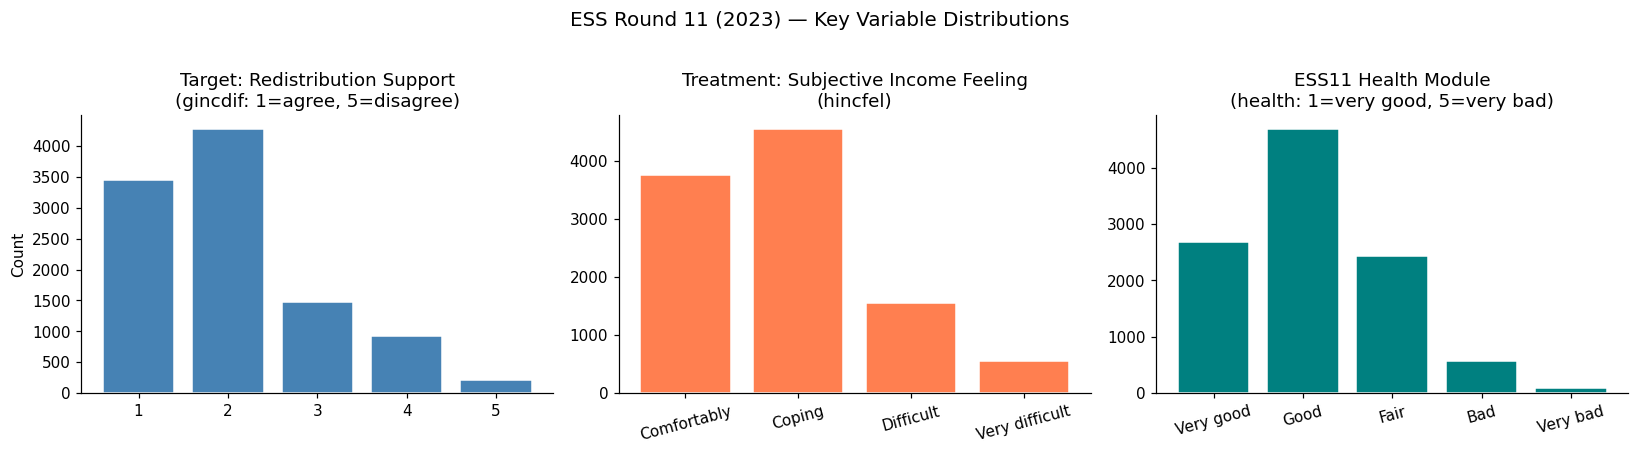

Naive mean-difference (T=1 vs T=0): -0.524
Positive = struggling group shows LESS support for redistribution


In [11]:
# ── EDA 1: Key variable distributions ────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Target ---
if Y_COL in df.columns:
    gc = df[Y_COL].dropna().astype(int).value_counts().sort_index()
    axes[0].bar(gc.index, gc.values, color='steelblue', edgecolor='white')
    axes[0].set_title('Target: Redistribution Support\n(gincdif: 1=agree, 5=disagree)')
    axes[0].set_ylabel('Count')
    axes[0].set_xticks([1,2,3,4,5])

# --- Treatment ---
if 'hincfel' in df.columns:
    hmap = {1:'Comfortably', 2:'Coping', 3:'Difficult', 4:'Very difficult'}
    hc = df['hincfel'].dropna().astype(int).value_counts().sort_index()
    valid_keys = [k for k in hc.index if k in hmap]
    axes[1].bar([hmap[k] for k in valid_keys],
                hc[valid_keys].values, color='coral', edgecolor='white')
    axes[1].set_title('Treatment: Subjective Income Feeling\n(hincfel)')
    axes[1].tick_params(axis='x', rotation=15)

# --- Health (ESS11 module) ---
if 'health' in df.columns:
    hlmap = {1:'Very good', 2:'Good', 3:'Fair', 4:'Bad', 5:'Very bad'}
    hlc = df['health'].dropna().astype(int).value_counts().sort_index()
    valid_keys = [k for k in hlc.index if k in hlmap]
    axes[2].bar([hlmap[k] for k in valid_keys],
                hlc[valid_keys].values, color='teal', edgecolor='white')
    axes[2].set_title('ESS11 Health Module\n(health: 1=very good, 5=very bad)')
    axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('ESS Round 11 (2023) — Key Variable Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()

if T_COL in df.columns and Y_COL in df.columns:
    ct = df.groupby(T_COL, dropna=True)[Y_COL].mean()
    if len(ct) >= 2:
        diff = ct.iloc[1] - ct.iloc[0]
        print(f'Naive mean-difference (T=1 vs T=0): {diff:.3f}')
        print('Positive = struggling group shows LESS support for redistribution')

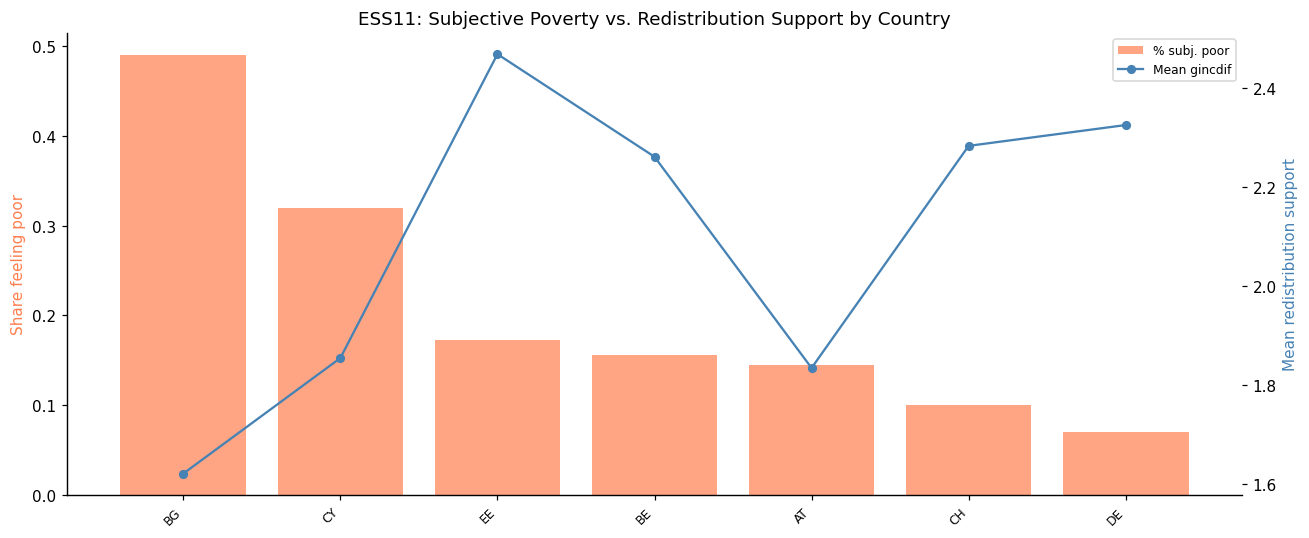

          n  mean_gincdif  pct_poor
cntry                              
BG     1998         1.622     0.490
CY      605         1.855     0.319
EE      402         2.468     0.172
BE     1519         2.261     0.156
AT     2190         1.835     0.144
CH     1309         2.283     0.100
DE     2314         2.325     0.070


In [12]:
# ── EDA 2: Country overview ───────────────────────────────────────────────────

if 'cntry' in df.columns:
    agg_dict = {'n': (Y_COL,'count'), 'mean_gincdif': (Y_COL,'mean')}
    if T_COL in df.columns:
        agg_dict['pct_poor'] = (T_COL,'mean')

    country_stats = (
        df.groupby('cntry', dropna=True)
        .agg(**agg_dict)
        .sort_values('pct_poor' if 'pct_poor' in agg_dict else 'mean_gincdif',
                     ascending=False)
        .round(3)
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(country_stats))
    ax2 = ax.twinx()
    if 'pct_poor' in country_stats.columns:
        ax.bar(x, country_stats['pct_poor'], color='coral', alpha=0.7, label='% subj. poor')
    ax2.plot(x, country_stats['mean_gincdif'], 'o-', color='steelblue',
             linewidth=1.5, markersize=5, label='Mean gincdif')
    ax.set_xticks(x)
    ax.set_xticklabels(country_stats.index, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Share feeling poor', color='coral')
    ax2.set_ylabel('Mean redistribution support', color='steelblue')
    ax.set_title('ESS11: Subjective Poverty vs. Redistribution Support by Country')
    lines1,labels1 = ax.get_legend_handles_labels()
    lines2,labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labels1+labels2, loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.savefig('eda_country.png', bbox_inches='tight')
    plt.show()
    print(country_stats.to_string())

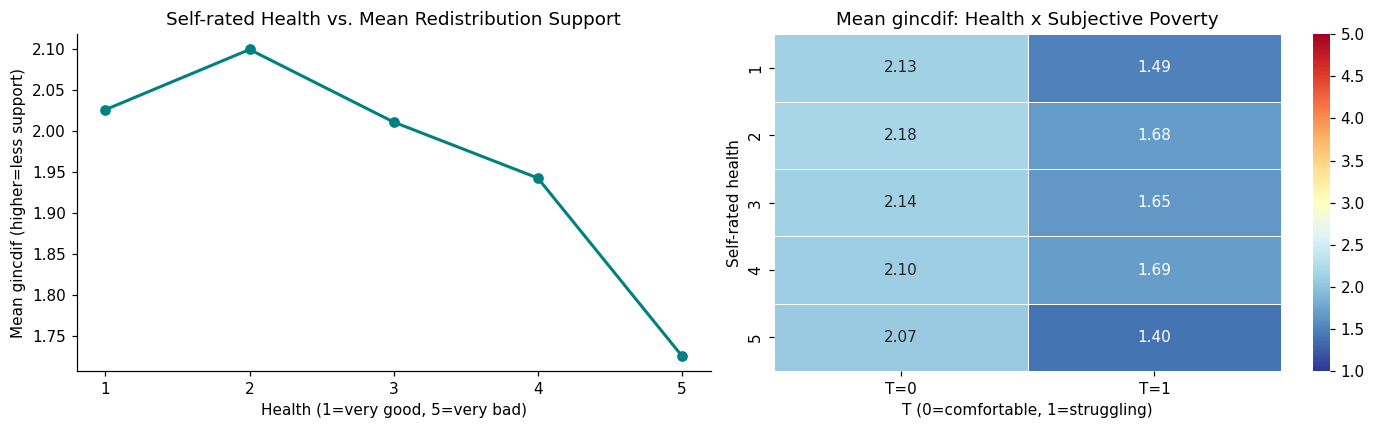

In [13]:
# ── EDA 3: Health module (ESS11-specific) ────────────────────────────────────

if 'health' in df.columns and T_COL in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ht = df.groupby('health', dropna=True)[Y_COL].mean()
    axes[0].plot(ht.index.astype(int), ht.values, 'o-', color='teal', linewidth=2)
    axes[0].set_title('Self-rated Health vs. Mean Redistribution Support')
    axes[0].set_xlabel('Health (1=very good, 5=very bad)')
    axes[0].set_ylabel('Mean gincdif (higher=less support)')
    axes[0].set_xticks([1,2,3,4,5])

    tmp = df.dropna(subset=[T_COL,'health']).copy()
    tmp['health'] = tmp['health'].astype(int)
    pivot = tmp.groupby(['health', T_COL])[Y_COL].mean().unstack(T_COL)
    pivot.columns = [f'T={int(c)}' for c in pivot.columns]
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlBu_r',
                vmin=1, vmax=5, ax=axes[1], linewidths=0.5)
    axes[1].set_title('Mean gincdif: Health x Subjective Poverty')
    axes[1].set_xlabel('T (0=comfortable, 1=struggling)')
    axes[1].set_ylabel('Self-rated health')

    plt.tight_layout()
    plt.savefig('eda_health.png', bbox_inches='tight')
    plt.show()

Schwartz items with sufficient data: 21


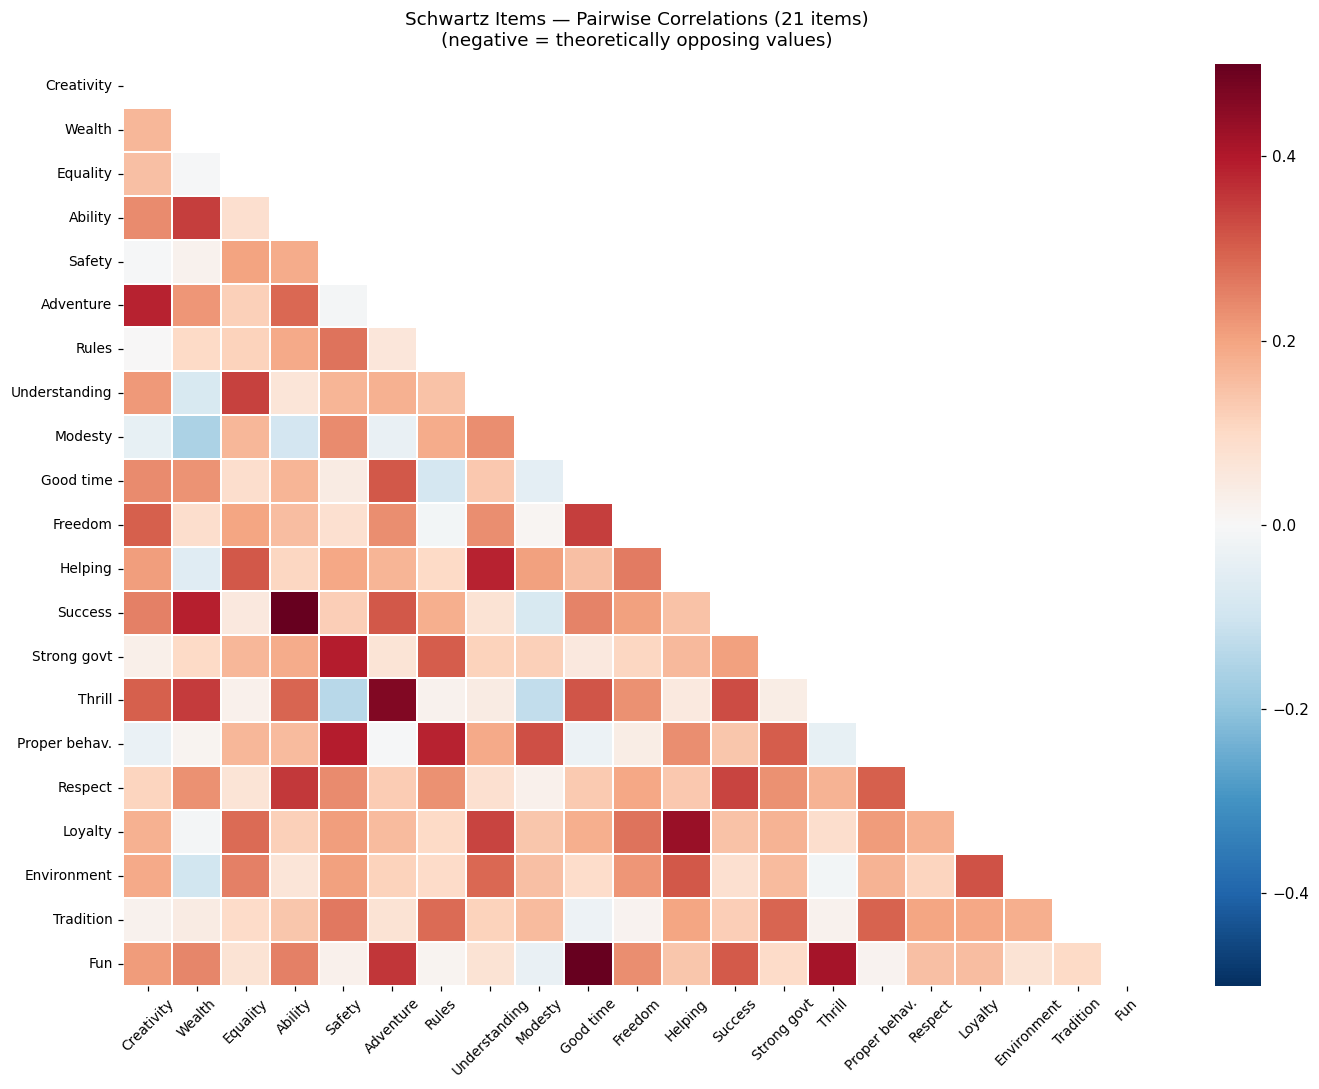

Heatmap saved (21x21 correlation matrix).


In [14]:
# ── EDA 4: Schwartz correlation heatmap ──────────────────────────────────────
# Fixed: guards against empty schwartz_present and non-numeric columns

assert len(schwartz_present) > 0, 'No Schwartz items found — check Setup cell output.'

# Force numeric and check we have at least 2 valid columns
sw_numeric = df[schwartz_present].apply(pd.to_numeric, errors='coerce')
valid_sw   = [c for c in schwartz_present if sw_numeric[c].notna().sum() > 100]
valid_lbls = [schwartz_labels[schwartz_present.index(c)] for c in valid_sw]

print(f'Schwartz items with sufficient data: {len(valid_sw)}')
assert len(valid_sw) >= 2, \
    f'Only {len(valid_sw)} valid Schwartz columns — cannot compute correlations.'

corr = sw_numeric[valid_sw].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    vmin=-0.5, vmax=0.5,
    linewidths=0.3,
    annot=len(valid_sw) <= 12,   # only annotate if small enough to read
    fmt='.2f',
    xticklabels=valid_lbls,
    yticklabels=valid_lbls,
    ax=ax
)
ax.set_title(
    f'Schwartz Items — Pairwise Correlations ({len(valid_sw)} items)\n'
    '(negative = theoretically opposing values)',
    pad=12
)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.savefig('schwartz_correlations.png', bbox_inches='tight')
plt.show()
print(f'Heatmap saved ({len(valid_sw)}x{len(valid_sw)} correlation matrix).')

## 4. Planned Methods

Your mission **must** apply at least one technique from **each** of the three blocks below. Tick the ones you plan to use and briefly justify the choice.

### 4a. Causal Inference
- [x] Causal graph / DAG (DoWhy)
- [x] Backdoor adjustment
- [ ] Instrumental variable
- [ ] Propensity score stratification
- [ ] Other: ___

*Justification:*

### 4b. Supervised Learning
- [ ] Linear / Ridge / Lasso regression
- [x] Logistic regression
- [ ] k-Nearest Neighbors
- [ ] Support Vector Machine
- [x] Decision Tree / Random Forest
- [ ] Neural network (regression or classification)
- [ ] Other: ___

*Justification:*

### 4c. Unsupervised Learning / Generative Models
- [x] K-Means clustering
- [ ] Hierarchical clustering
- [ ] Variational autoencoder
- [ ] GAN
- [ ] Other: ___

*Justification:*


## 5. Evaluation Strategy

| Block | Metric | Validation | Baseline |
|-------|--------|-----------|----------|
| Causal | ATE with 95% CI | 3 DoWhy refutations | Naive diff-in-means |
| Supervised | AUC-ROC | Stratified 5-fold CV | Majority-class |
| Unsupervised | Silhouette score | Elbow plot k=2..8 | Schwartz 4-cluster theory |

## 6. Work Plan

| Step | Owner | Description |
|------|-------|-------------|
| 1 | Nishandhine | Download ESS11, clean and extract required features |
| 2 | Suyashi | EDA — all plots above |
| 3 | Nishandhine + Suyashi | 7c: K-Means, label archetypes |
| 4 | Nishandhine| 7a: DoWhy DAG + health confounder + refutations |
| 5 | Suyashi | 7b: Logistic + RF, CV, feature importances |
| 6 | Nishandhine + Suyashi | Synthesis + Section 8 write-up |

---
## 7. Results *(complete for final submission)*


### 7a. Causal Inference

In [ ]:
# Causal inference analysis

### 7b. Supervised Learning

In [ ]:
# Supervised learning analysis

### 7c. Unsupervised / Generative

In [ ]:
# Unsupervised / generative analysis

## 8. Discussion & Conclusion *(complete for final submission)*

*Synthesise findings across all three method blocks. What does each lens reveal that the others miss? What are the limitations of your analysis?*
